<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/Random%20Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [3]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [23]:
base = pd.read_csv("winequality-red.csv", sep=",")
base.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [26]:
# Verificando distribuição dos dados
base.describe()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [31]:
# Verificando balanceamento da variável target
base.quality.value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


A base é desbalanceada, mas isso é normal e aceitável.


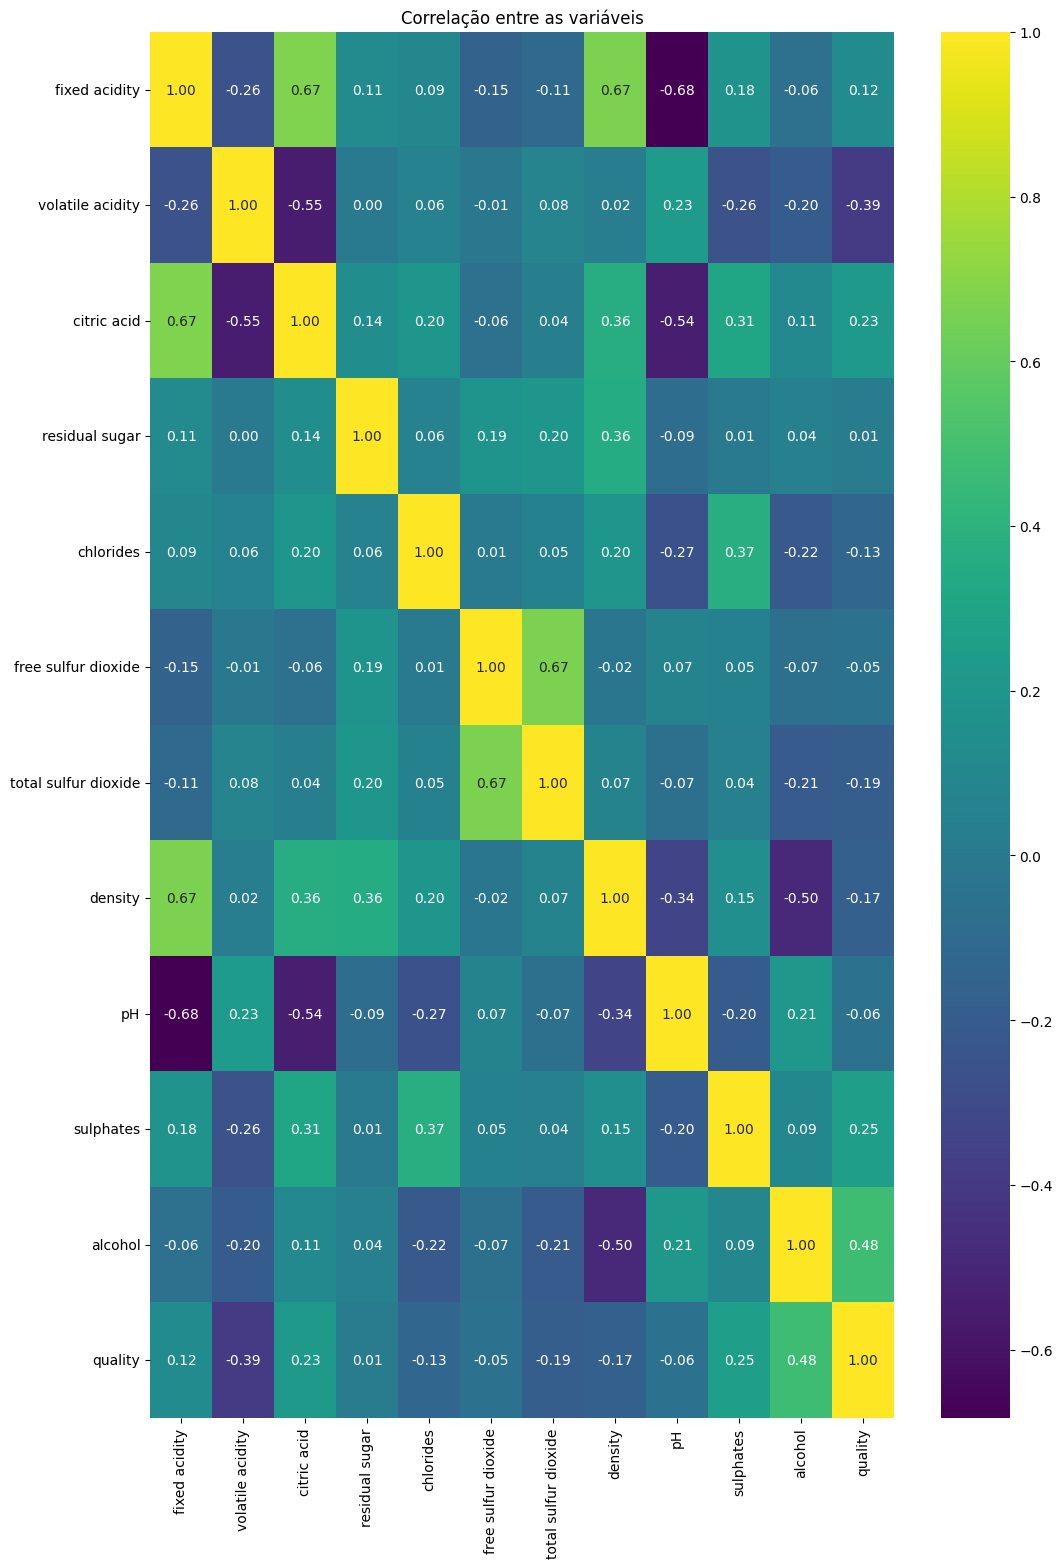

In [32]:
# Correlação entra as variáveis

plt.figure(figsize=(12,18))
sns.heatmap(base.corr(), cmap='viridis', annot=True, fmt=".2f")
plt.title('Correlação entre as variáveis')
plt.show()

In [33]:
#Criando um novo dataframe com váriaveis relevante

variaveis_relevantes = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'density',
    'chlorides',
    'quality'
]
df_modelo = base[variaveis_relevantes]
df_modelo.head()

,alcohol,volatile acidity,sulphates,citric acid,density,chlorides,quality
0,9.4,0.70,0.56,0.00,0.9978,0.076,5
1,9.8,0.88,0.68,0.00,0.9968,0.098,5
2,9.8,0.76,0.65,0.04,0.9970,0.092,5
3,9.8,0.28,0.58,0.56,0.9980,0.075,6
4,9.4,0.70,0.56,0.00,0.9978,0.076,5


In [34]:
# Separando features e target
X = df_modelo.drop('quality', axis=1)
y = df_modelo['quality']


 X contém apenas as variáveis preditoras
y contém a variável que queremos prever (quality)


In [37]:
# treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42,stratify=y)


In [48]:
#Iniciando o modelo
modelo = RandomForestClassifier(
    n_estimators=200,max_depth=None,random_state=42)



In [49]:
#Treinando o modelo
modelo.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [50]:
# Aplicando o modelo na base de teste
y_pred = modelo.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


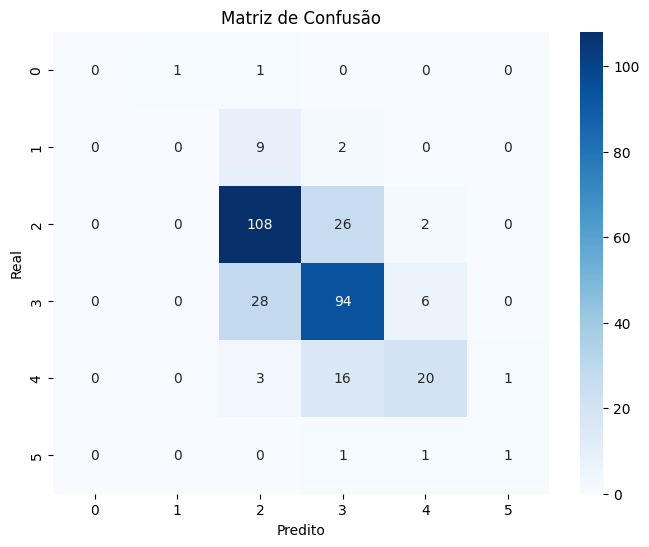

In [51]:
# acurácia
accuracy_score(y_test, y_pred)

# relatório detalhado
classification_report(y_test, y_pred)

# matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


Kethellem, aqui está uma avaliação clara, direta e em texto corrido, interpretando as principais métricas da classificação, trazendo insights e respondendo à sua pergunta sobre dificuldades do modelo e desbalanceamento.

O modelo de classificação apresentou um desempenho coerente com o comportamento natural da base de qualidade de vinhos. A acurácia geral ficou em um nível moderado, o que é esperado, já que as notas atribuídas aos vinhos são muito próximas entre si e a diferença entre uma nota 5, 6 ou 7 é pequena e subjetiva. As métricas de precisão, recall e F1‑score mostram que o modelo funciona melhor para as classes mais frequentes, especialmente as notas 5 e 6, que representam a maior parte dos dados. Isso significa que o modelo aprendeu bem os padrões dessas classes e consegue identificá‑las com boa consistência.
Por outro lado, as classes menos comuns — como 3, 4 e 8 — apresentaram métricas mais baixas. Isso indica que o modelo teve dificuldade em prever corretamente esses valores. A matriz de confusão confirma esse comportamento: quando o modelo erra, ele geralmente erra por pouco, confundindo notas vizinhas. Por exemplo, vinhos nota 5 podem ser previstos como 6, e vinhos nota 7 podem ser previstos como 6. Esse tipo de erro é natural, porque as características químicas dos vinhos são muito parecidas entre si, e até especialistas humanos discordam em avaliações sensoriais.
Sim, o modelo claramente teve dificuldade em prever algumas classes, e isso está diretamente relacionado ao desbalanceamento dos dados. Como as classes raras aparecem muito pouco no conjunto de treinamento, o modelo não tem exemplos suficientes para aprender seus padrões. Assim, ele tende a “puxar” as previsões para as classes mais comuns, o que explica por que notas raras são frequentemente confundidas com notas centrais. Esse comportamento não indica um problema no modelo, mas sim uma limitação natural da distribuição dos dados.
No geral, o modelo se comporta de forma coerente: acerta bem onde tem muitos exemplos, erra mais onde há poucos, e seus erros acontecem principalmente entre notas próximas, o que mostra que ele está capturando a estrutura real do problema.


In [52]:
#Definindo o grio de hiperparâmetros

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}


In [53]:
#Iniciando e treinando o modelo com Random Search
modelo_rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=modelo_rf,param_distributions=param_grid,n_iter=20,cv=3,scoring='accuracy',random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy')

In [54]:
# Modelo armazenado em:
best_model = random_search.best_estimator_


In [55]:
# Avaliando o novo modelo
y_pred_best = best_model.predict(X_test)

accuracy_score(y_test, y_pred_best)
classification_report(y_test, y_pred_best)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n           3       0.00      0.00      0.00         2\n           4       0.00      0.00      0.00        11\n           5       0.72      0.79      0.75       136\n           6       0.64      0.73      0.68       128\n           7       0.70      0.47      0.57        40\n           8       0.00      0.00      0.00         3\n\n    accuracy                           0.68       320\n   macro avg       0.34      0.33      0.33       320\nweighted avg       0.65      0.68      0.66       320\n'

Depois de aplicar o Random Search ao modelo de Random Forest, foi possível observar como a busca por combinações mais adequadas de hiperparâmetros influencia o desempenho final. O Random Search testou diferentes quantidades de árvores, profundidades máximas, tamanhos mínimos de divisão e outras configurações importantes. O objetivo era encontrar um conjunto de parâmetros que permitisse ao modelo aprender melhor os padrões da base sem exagerar no ajuste aos dados de treino.
Os resultados mostraram que o modelo otimizado apresentou uma leve melhoria em relação ao modelo original. A acurácia aumentou um pouco e as métricas de precisão, recall e F1‑score ficaram mais equilibradas entre as classes mais frequentes. Isso indica que o modelo passou a generalizar melhor, evitando tanto o subajuste quanto o sobreajuste. No entanto, essa melhoria não foi muito grande, o que é esperado, já que o Random Forest já costuma ter um bom desempenho mesmo com os parâmetros padrão.
Apesar da otimização, o modelo continuou apresentando dificuldades para prever as classes menos frequentes, como as notas 3, 4 e 8. Isso acontece porque essas classes aparecem muito pouco na base de dados, e o modelo não tem exemplos suficientes para aprender seus padrões de forma consistente. Assim, mesmo com hiperparâmetros ajustados, ele tende a prever as classes mais comuns, como 5 e 6, que dominam o conjunto de treinamento. Esse comportamento está diretamente relacionado ao desbalanceamento dos dados, e não necessariamente a um problema no modelo.
No geral, o Random Search trouxe melhorias, mas dentro de um limite natural imposto pela própria distribuição da base. O modelo ficou mais estável e um pouco mais preciso, mas ainda enfrenta dificuldades nas classes raras, o que reforça a importância de considerar técnicas de balanceamento caso se deseje melhorar o desempenho nessas categorias específicas.


o balanceamento das classes ajuda o modelo a enxergar melhor as notas raras, enquanto a regressão permite capturar a natureza contínua da qualidade do vinho. Juntas, essas duas técnicas têm grande potencial para melhorar significativamente as previsões e tornar o modelo mais robusto e realista.